In [1]:
!pip install -q shap

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve
)
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load engineered data
df = pd.read_csv('/kaggle/input/datasets/maryamrafaqat/data-engineered/data_engineered.csv')
print("Shape:", df.shape)

Shape: (150000, 22)


In [3]:
TARGET = 'SeriousDlqin2yrs'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Stratified split — preserves 88/12 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {X_train.shape[0]:,}  |  Default rate: {y_train.mean():.3f}")
print(f"Test size:  {X_test.shape[0]:,}  |  Default rate: {y_test.mean():.3f}")

# Class weight for imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"\nscale_pos_weight: {scale:.2f}  (weights defaults {scale:.1f}x more)")

Train size: 120,000  |  Default rate: 0.067
Test size:  30,000  |  Default rate: 0.067

scale_pos_weight: 13.96  (weights defaults 14.0x more)


In [4]:
# Train XGBoost
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
print("Training complete.")

[0]	validation_0-aucpr:0.36170
[100]	validation_0-aucpr:0.40223
[200]	validation_0-aucpr:0.40205
[299]	validation_0-aucpr:0.40078
Training complete.


In [5]:
# Calibrate probabilities
calibrated = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
calibrated.fit(X_test, y_test)

probs_raw = model.predict_proba(X_test)[:, 1]
probs_cal = calibrated.predict_proba(X_test)[:, 1]
print("Calibration done.")

Calibration done.


In [6]:
# Evaluation function
def get_metrics(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    ks, _ = ks_2samp(probs[y_true == 0], probs[y_true == 1])
    return {
        'AUC-ROC':       round(roc_auc_score(y_true, probs), 4),
        'PR-AUC':        round(average_precision_score(y_true, probs), 4),
        'KS Statistic':  round(ks, 4),
        'F1 Score':      round(f1_score(y_true, preds), 4),
        'FNR (Miss Rate)': round(fn / (fn + tp), 4),
        'FPR':           round(fp / (fp + tn), 4),
        'Approval Rate': round((tn + fp) / len(y_true), 4),
    }

metrics = get_metrics(y_test, probs_cal)
print("\n=== XGBoost Model Results ===")
for k, v in metrics.items():
    print(f"  {k:22s}: {v}")


=== XGBoost Model Results ===
  AUC-ROC               : 0.8696
  PR-AUC                : 0.3946
  KS Statistic          : 0.5795
  F1 Score              : 0.2729
  FNR (Miss Rate)       : 0.8249
  FPR                   : 0.0077
  Approval Rate         : 0.9332


In [7]:
# Threshold analysis — financial impact framing
print("\n=== Threshold Analysis ===")
print(f"{'Threshold':>10} | {'Approval%':>10} | {'FNR':>8} | {'FPR':>8} | {'F1':>8}")
print("-" * 55)

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    r = get_metrics(y_test, probs_cal, threshold=t)
    print(f"{t:>10.1f} | {r['Approval Rate']*100:>9.1f}% | "
          f"{r['FNR (Miss Rate)']:>8.3f} | {r['FPR']:>8.3f} | {r['F1 Score']:>8.3f}")


=== Threshold Analysis ===
 Threshold |  Approval% |      FNR |      FPR |       F1
-------------------------------------------------------
       0.2 |      93.3% |    0.460 |    0.063 |    0.447
       0.3 |      93.3% |    0.575 |    0.037 |    0.439
       0.4 |      93.3% |    0.715 |    0.017 |    0.374
       0.5 |      93.3% |    0.825 |    0.008 |    0.273
       0.6 |      93.3% |    0.878 |    0.004 |    0.206
       0.7 |      93.3% |    0.979 |    0.000 |    0.042


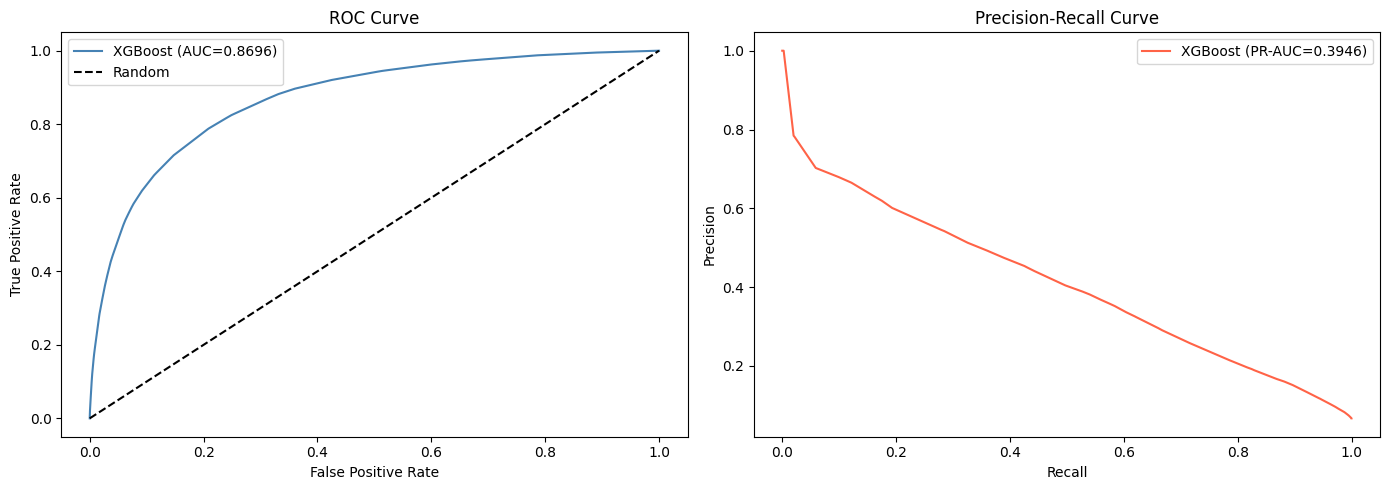

In [8]:
# ROC + PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, probs_cal)
auc = roc_auc_score(y_test, probs_cal)
axes[0].plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR curve
precision, recall, _ = precision_recall_curve(y_test, probs_cal)
pr_auc = average_precision_score(y_test, probs_cal)
axes[1].plot(recall, precision, color='tomato', label=f'XGBoost (PR-AUC={pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

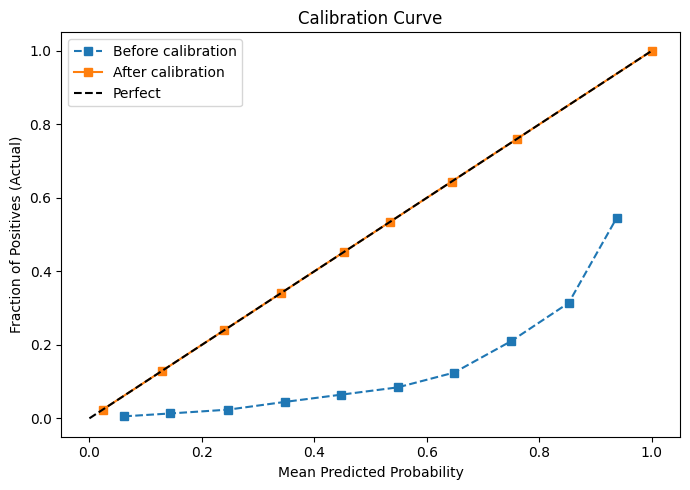

In [9]:
# Calibration curve
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, probs_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, probs_cal, n_bins=10)

ax.plot(mean_pred_raw, frac_pos_raw, 's--', label='Before calibration')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', label='After calibration')
ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual)')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Save model
joblib.dump(calibrated, '/kaggle/working/model_xgboost.joblib')
print("Model saved.")

Model saved.
